## Libraries


In [40]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Version control of Tor

In [2]:
#@title checking version of torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu130
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


ERROR: Could not find a version that satisfies the requirement mlp_toolkits (from versions: none)
ERROR: No matching distribution found for mlp_toolkits


In [13]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler


In [41]:
def plotPerColumnDistro(df, n_graph_shown, n_graph_per_row):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]]

    n_row, n_col = df.shape
    column_names = list(df)

    n_graph_row = (n_col + n_graph_per_row - 1) // n_graph_per_row

    plt.figure(figsize=(6 * n_graph_per_row, 8 * n_graph_row))

    for i in range(min(n_col, n_graph_shown)):
        plt.subplot(n_graph_row, n_graph_per_row, i + 1)
        col_df = df.iloc[:, i]

        if not pd.api.types.is_numeric_dtype(col_df):
            col_df.value_counts().plot.bar()
        else:
            col_df.hist()

        plt.ylabel('counts')
        plt.xticks(rotation=90)
        plt.title(f"{column_names[i]} (column {i})")

    plt.tight_layout()
    plt.show()

In [54]:
def plotCorrelationMatrix(df, graphWidth, name="DataFrame"):
    df = df.dropna(axis=1, thresh=int(0.7 * len(df)))     
    df = df[[col for col in df if df[col].nunique() > 1]]
    df = df.select_dtypes(include=[np.number])

    if df.shape[1] < 2:
        print(f'No correlation plots shown: The number of valid columns ({df.shape[1]}) is less than 2')
        return

    corr = df.corr()

    fig, ax = plt.subplots(figsize=(graphWidth, graphWidth))
    cax = ax.matshow(corr)

    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.columns)

    ax.xaxis.tick_bottom()
    fig.colorbar(cax)

    plt.title(f'Correlation Matrix for {name}', y=1.2)
    plt.show()


In [64]:
def plot_scatter_matrix(df, plot_size, text_size):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df = df.select_dtypes(include=[np.number])
    df = df.dropna(axis=1, how='all')
    df = df[[col for col in df if df[col].nunique() > 1]]

    column_names = list(df)
    if len(column_names) > 10:
        column_names = column_names[:10]

    df = df[column_names]

    ax = pd.plotting.scatter_matrix(
        df,
        alpha=0.75,
        figsize=(plot_size, plot_size),
        diagonal='kde'
    )

    corrs = df.corr().values

    for i, j in zip(*np.triu_indices_from(corrs, k=1)):
        ax[i, j].annotate(
            f'Corr = {corrs[i, j]:.3f}',
            (0.8, 0.2),
            xycoords='axes fraction',
            ha='center',
            size=text_size
        )

    plt.suptitle("Scatter and density plots")
    plt.show()

In [34]:
n_rows_read=1000
df1=pd.read_csv("../data/well_log.csv", delimiter=',', nrows=n_rows_read)
df1.dataframeName='well_log.csv'
n_row, n_col=df1.shape
print(f'There are {n_row} rows and {n_col} columns')


There are 1000 rows and 29 columns


In [45]:
df1.head(10)


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-23,1518.280,433906.75000,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,NaN,...,146.526276,326.451263,-1.993768,0.109706,NaN,NaN,88.968864,NaN,65000,3.0
1,15/9-23,1518.432,433906.75000,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,NaN,...,147.605148,322.926361,1.024611,-0.006418,NaN,NaN,92.287186,NaN,65000,3.0
2,15/9-23,1518.584,433906.75000,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,NaN,...,140.783127,325.283142,1.355668,0.022769,NaN,NaN,95.605499,NaN,65000,3.0
3,15/9-23,1518.736,433906.75000,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,NaN,...,125.159531,334.233185,1.663353,0.024972,NaN,NaN,98.923820,NaN,65000,3.0
4,15/9-23,1518.888,433906.75000,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,NaN,0.849849,...,107.576691,330.952362,0.989743,0.024527,NaN,NaN,102.242142,NaN,65000,3.0
5,15/9-23,1519.040,433906.75000,6460000.5,-1494.001709,HORDALAND GP.,Skade Fm.,15.919361,NaN,0.929877,...,112.974251,316.437927,-1.580639,0.019025,NaN,NaN,104.174736,NaN,65000,3.0
6,15/9-23,1519.192,433906.78125,6460000.5,-1494.153687,HORDALAND GP.,Skade Fm.,13.566401,NaN,0.973370,...,123.193176,316.381134,-3.933601,-0.008151,NaN,NaN,102.227287,NaN,65000,3.0
7,15/9-23,1519.344,433906.78125,6460000.5,-1494.305664,HORDALAND GP.,Skade Fm.,12.201807,NaN,1.020846,...,136.225769,319.537354,-5.298192,-0.029403,NaN,NaN,100.279846,NaN,65000,3.0
8,15/9-23,1519.496,433906.78125,6460000.5,-1494.457642,HORDALAND GP.,Skade Fm.,12.069018,NaN,1.064951,...,135.401993,328.520630,-5.430982,-0.051000,NaN,NaN,98.332405,NaN,65000,3.0
9,15/9-23,1519.648,433906.78125,6460000.5,-1494.609619,HORDALAND GP.,Skade Fm.,12.012268,NaN,1.079303,...,114.421364,335.690613,-5.487732,-0.084551,NaN,NaN,96.384964,NaN,65000,3.0


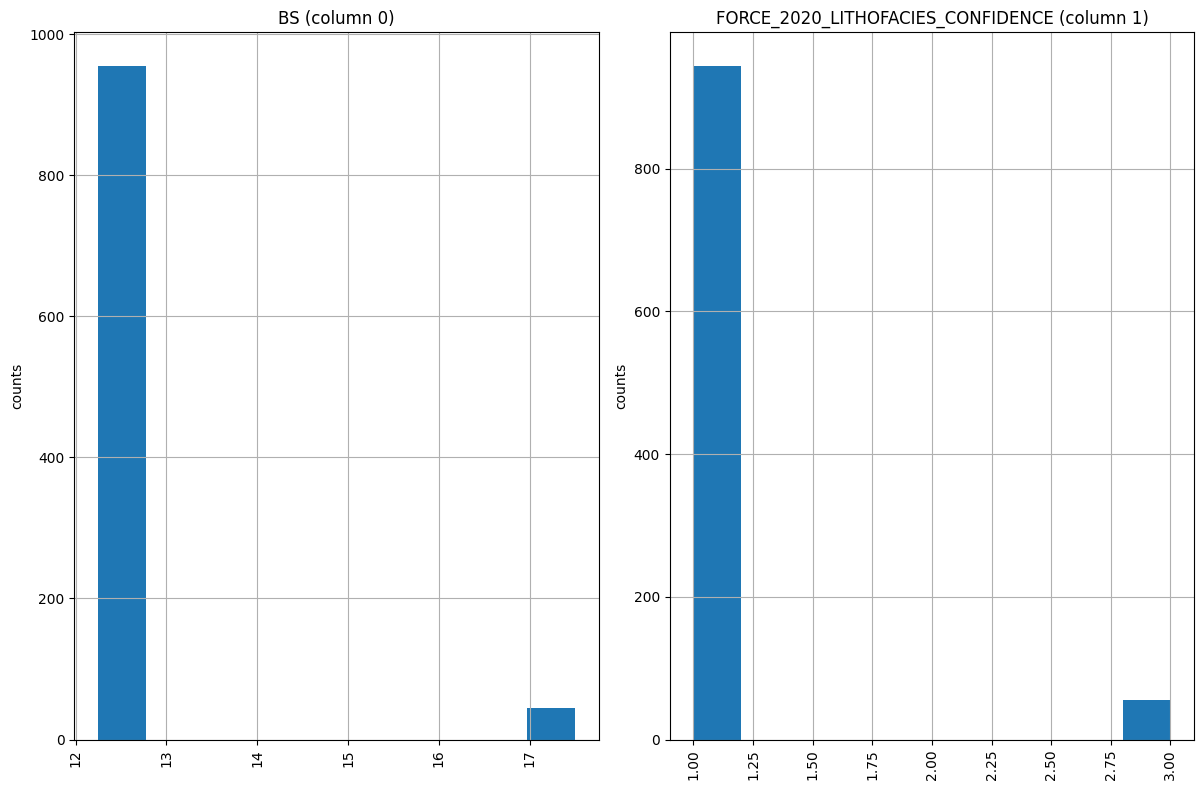

In [49]:
plotPerColumnDistro(df1, 10,5)

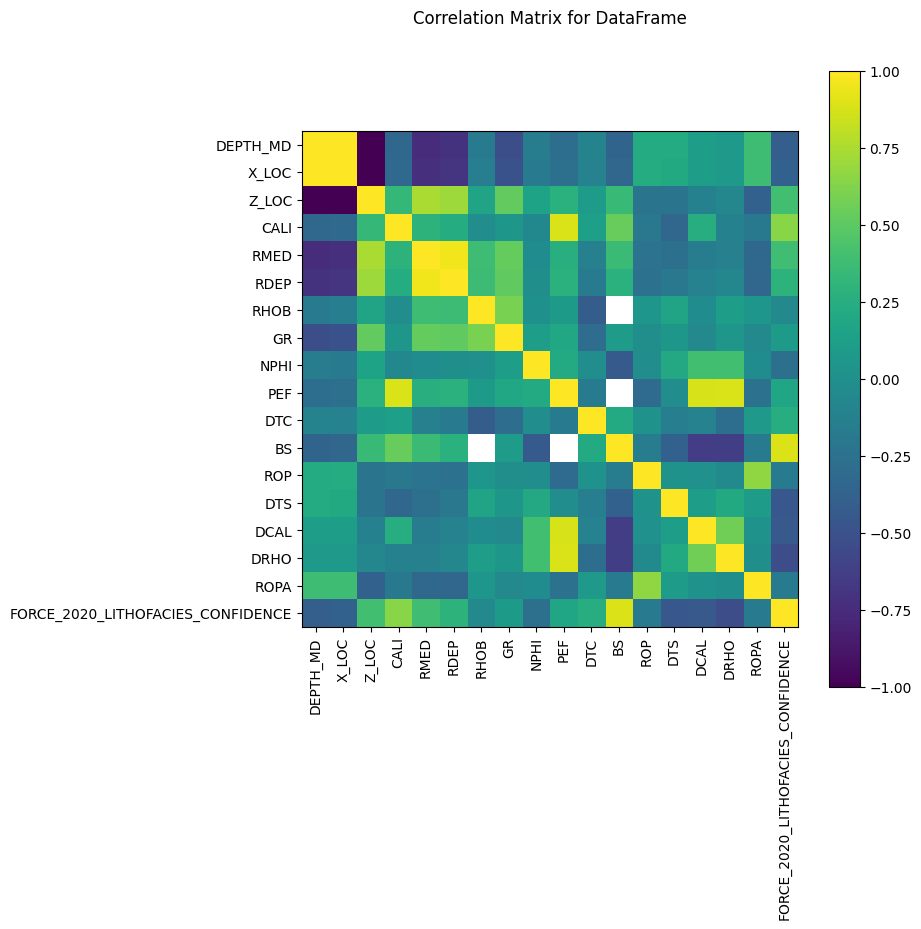

In [61]:
plotCorrelationMatrix(df1, 8)

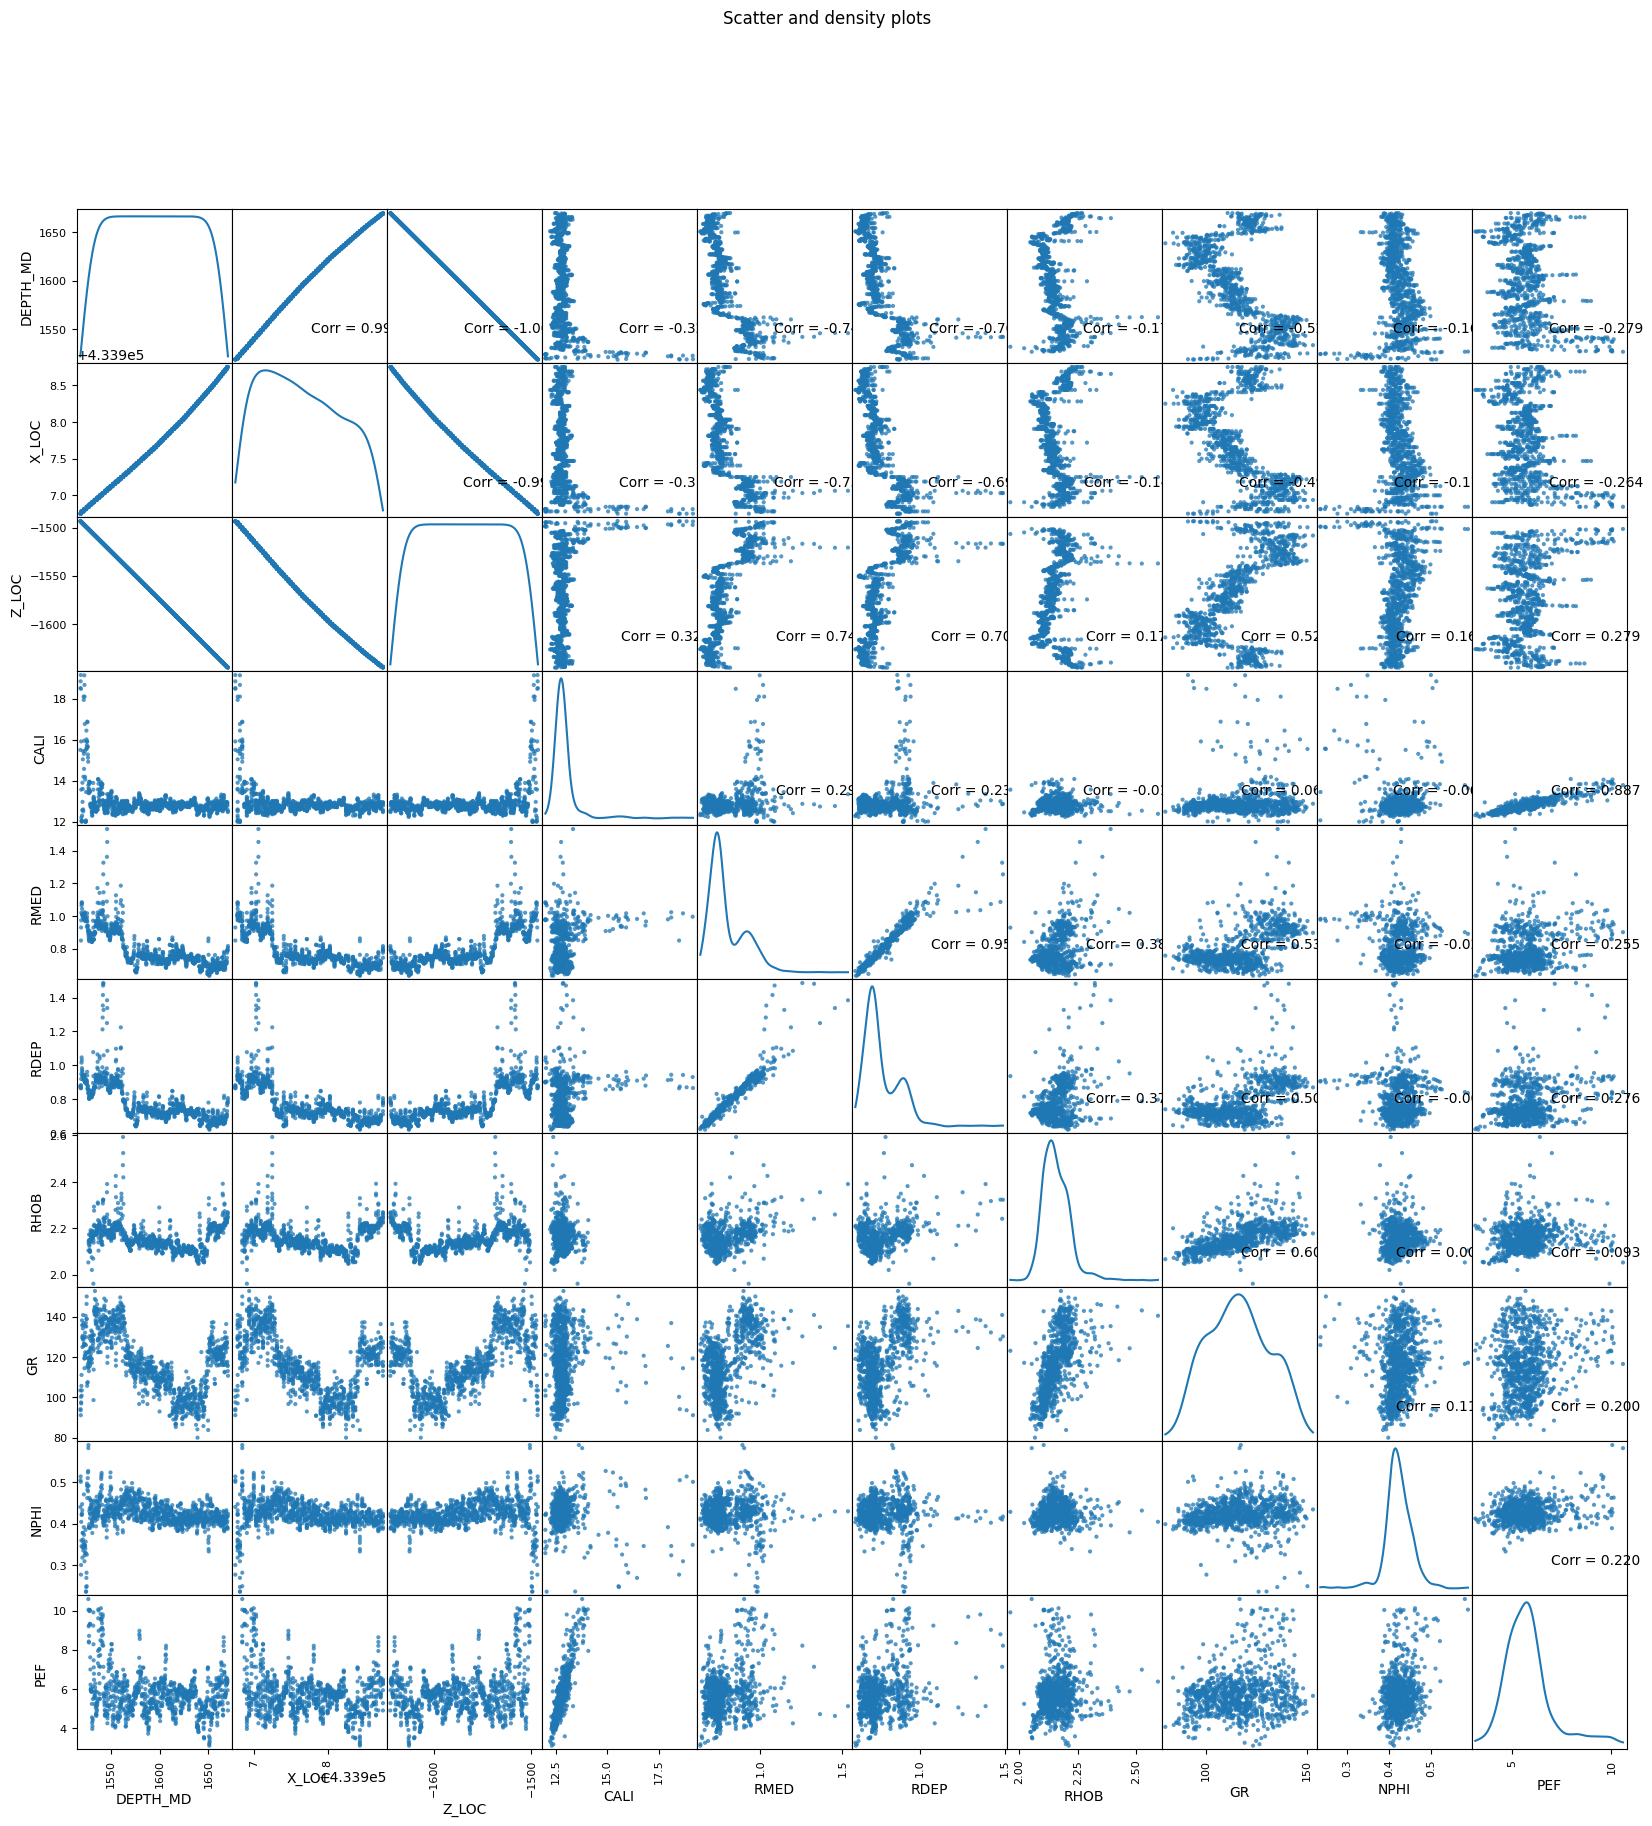

In [65]:
plot_scatter_matrix(df1, 20, 10)